**Implementation of MCP Neuron for AND and OR Function.**

AND Gate


In [13]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result)

AND Output: [0, 0, 0, 1]


OR Gate

In [14]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example
T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**Implementation for 0 Vs. 1 Classification.**



Step 1: Load the Dataset

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("/content/drive/MyDrive/DeepLearning/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12665, 784)
y shape: (12665,)


Viewing the Dataset.

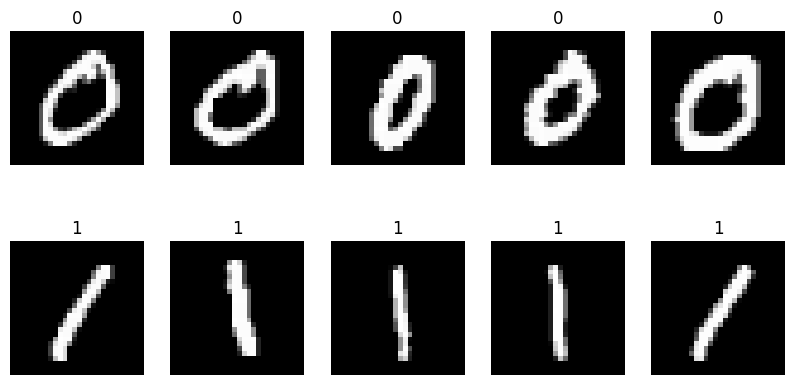

In [16]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("1")
    axes[1, i].axis("off")

plt.show()

Q1: Shape of X
(n_samples, 784)
Each row = one image
784 = 28×28 pixels

Q2: Shape of y
(n_samples,)
Contains labels (0 or 1)

Step - 2 - Initializing the Weights:

In [17]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

Answers

**Q3: What does the weights array represent in this context?**

Importance of each pixel in classification

**Q4: Why initializing weights to zero?**

Simple starting point
Model learns from scratch

Step - 3 - Make a Decision function:

In [18]:
import numpy as np

def decision_function(X, weights, bias):

    z = np.dot(X, weights) + bias
    y_pred_all = np.where(z >= 0, 1, 0)
    return y_pred_all

Step - 3 - Implement the Perceptron Learning Algorithm

In [19]:
import numpy as np
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    # Calculate accuracy
    predictions = decision_function(X, weights, bias)
    accuracy = np.mean(predictions == y)

    return weights, bias, accuracy

**Q5:What is the purpose of the output?**
Purpose of np.dot(X[i], weights) + bias

Computes weighted sum (decision boundary)

**Q6: What happen when prediction is wrong?**

Weights updated:
w = w + η(y - ŷ)x
b = b + η(y - ŷ)

**Q7: Importance of accuracy.**
Measures model performance
Expected ≈ ~100% for 0 vs 1 (linearly separable)

Training the Perceptron

In [20]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


Step 5: Visualize Misclassified Images

In [21]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


**Q8: misclassified_idx**

Stores indices of wrongly predicted samples

**Q9: If all correct?**

Model perfectly learned dataset
Data is linearly separable

# Task 3: Perceptron Algorithm for 3 vs 5 Classification

In [22]:
# Load the dataset
df_0_2 = pd.read_csv("/content/drive/MyDrive/DeepLearning/mnist_3_and_5.csv") # Add the correct file path if necessary
# Extract features and labels
X_second = df_0_2.drop(columns=["label"]).values # 784 pixels
y_second = df_0_2["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


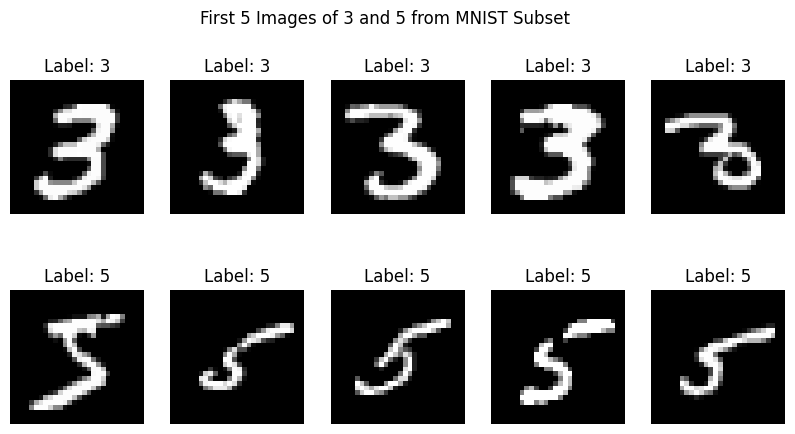

In [23]:
# Separate images for label 3 and label 5
images_0 = X_second[y_second == 3] # Get all images with label 3
images_1 = X_second[y_second == 5] # Get all images with label 5
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [24]:
# Initialize weights and bias
weights = np.zeros(X_second.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [25]:
y_second = np.where(y_second == 3, 0, 1)
weights = np.zeros(X_second.shape[1])

# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X_second, y_second, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.986866107260124


Final Accuracy: 0.9869


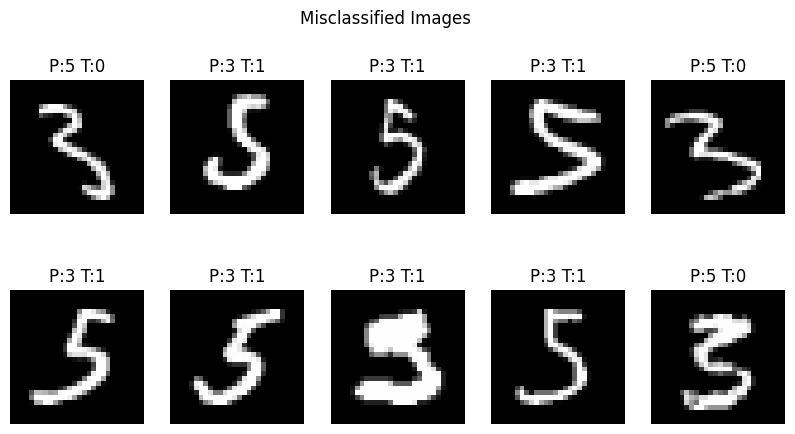

In [26]:
# Convert labels: 3 -> 0, 5 -> 1
y_binary = y_second

# ===== Predictions =====
predictions = np.dot(X_second, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Accuracy (correct comparison)
final_accuracy = np.mean(y_pred == y_binary)
print(f"Final Accuracy: {final_accuracy:.4f}")


# ===== Convert for visualization only =====
y_pred_labels = np.where(y_pred == 0, 3, 5)


# ===== Misclassified Images =====
misclassified_idx = np.where(y_pred != y_binary)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    # Turn off all axes first (clean look)
    for ax in axes.flat:
        ax.axis("off")

    # Plot up to 10 misclassified images
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X_second[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P:{y_pred_labels[idx]} T:{y_second[idx]}")

    plt.suptitle("Misclassified Images")
    plt.show()

else:
    print("All images were correctly classified!")